# ML performance vs. MD trajectory duration

Compares the binder/nonbinder Random Forest classifier's 7-fold grouped CV
performance across three feature tables, each built from the same features
computed over a different analysis window of the same trajectories:

- `feat_table_100ns.xlsx`  (40-100ns)
- `feat_table_250ns.xlsx`  (40-250ns)
- `feat_table_500ns_full.xlsx`  (40-500ns)

Each table is fully self-contained (built by `build_feat_table.py`), so
loading and running CV on it requires no runtime merging. The CV/model
pipeline itself is a verbatim copy of `ML_classification.ipynb`'s cell 5,
kept in `ml_utils.py` so this notebook can reuse it without modifying the
primary notebook.

Note: the repo-tracked `feat_table_500ns.xlsx` is *not* used directly here --
only 3 of the 8 feature families (dw_pocket, contact_type, rmsf) are baked
into it; the rest are merged in at runtime by `ML_classification.ipynb`'s
cell 1. `feat_table_500ns_full.xlsx` is a fully-merged regeneration built by
`build_feat_table.py --end-ns 500`, so this notebook compares like-for-like
across all three durations. It's a separate file so the original tracked
`feat_table_500ns.xlsx` is never modified.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ml_utils

In [2]:
DURATIONS = [
    ("100ns", "feat_table_100ns.xlsx", "all_feats_100ns"),
    ("250ns", "feat_table_250ns.xlsx", "all_feats_250ns"),
    ("500ns", "feat_table_500ns_full.xlsx", "all_feats_500ns"),
]

missing = [path for _, path, _ in DURATIONS if not os.path.exists(path)]
if missing:
    raise FileNotFoundError(
        f"Missing feature table(s): {missing}. Run build_feat_table.py for each "
        f"missing duration first (see the 250ns/100ns Alpine execution steps)."
    )

results = {}
for label, path, sheet in DURATIONS:
    df, feature_cols, feature_group_cols = ml_utils.load_feat_table(path, sheet)
    metrics_df, metrics, seq_groups = ml_utils.run_cv(df, feature_cols, feature_group_cols)
    results[label] = {"df": df, "metrics_df": metrics_df, "metrics": metrics}
    n_binders = int(df["Label"].sum())
    n_total = len(df)
    print(f"\n=== {label} ({n_total} sequences, {n_binders} binders) ===")
    print(metrics_df.to_string())


=== 100ns (193 sequences, 53 binders) ===
                    Mean     SD
accuracy           0.816  0.046
balanced_accuracy  0.675  0.105
roc_auc            0.814  0.152
f1                 0.508  0.229
precision          0.800  0.355
recall             0.378  0.175



=== 250ns (193 sequences, 53 binders) ===
                    Mean     SD
accuracy           0.843  0.049
balanced_accuracy  0.722  0.111
roc_auc            0.830  0.145
f1                 0.585  0.221
precision          0.849  0.229
recall             0.475  0.205



=== 500ns (193 sequences, 53 binders) ===
                    Mean     SD
accuracy           0.837  0.054
balanced_accuracy  0.708  0.138
roc_auc            0.838  0.151
f1                 0.540  0.293
precision          0.750  0.330
recall             0.453  0.267


Saved -> analysis/ML/ML_duration_comparison.png


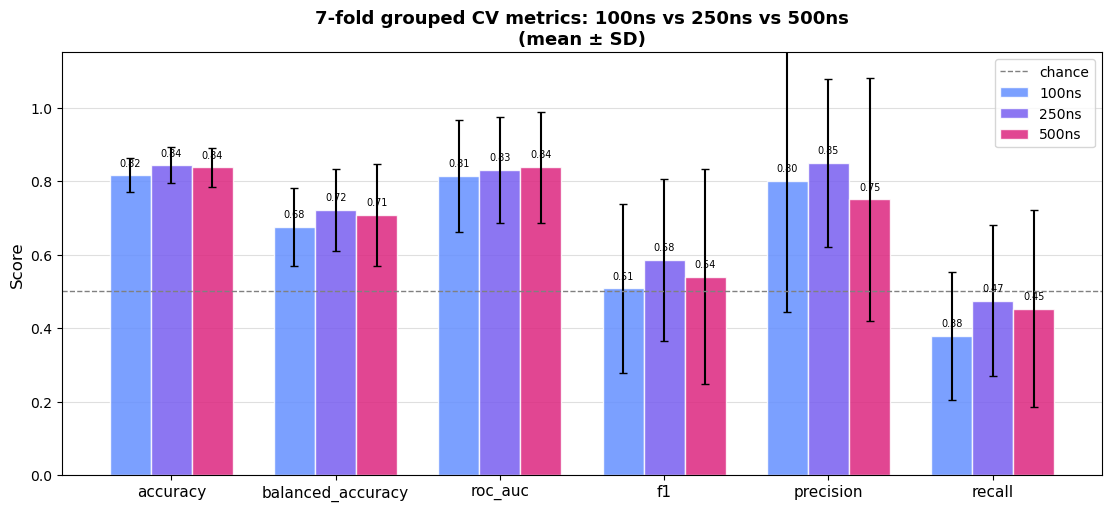

In [3]:
# ── Grouped bar chart: one group of bars per metric, one color per duration ──
# Colors are three hues from the project's existing IBM colorblind-safe
# palette (CLAUDE.md's GROUP_COLOR), reused here for a different semantic
# axis (duration, not classification group).
DURATION_COLOR = {"100ns": "#648FFF", "250ns": "#785EF0", "500ns": "#DC267F"}

metric_names = list(results["500ns"]["metrics_df"].index)
x = np.arange(len(metric_names))
width = 0.25
offsets = {"100ns": -width, "250ns": 0.0, "500ns": width}

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for label, _, _ in DURATIONS:
    m = results[label]["metrics_df"]
    means = m.loc[metric_names, "Mean"].values
    sds = m.loc[metric_names, "SD"].values
    bars = ax.bar(x + offsets[label], means, width, yerr=sds, capsize=3,
                   color=DURATION_COLOR[label], alpha=0.85, label=label, edgecolor="white")
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{mean:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")
ax.set_title(f"{ml_utils.N_SPLITS}-fold grouped CV metrics: 100ns vs 250ns vs 500ns\n(mean \u00b1 SD)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4, axis="y")
ax.set_axisbelow(True)

out_dir = "analysis"
os.makedirs(os.path.join(out_dir, "ML"), exist_ok=True)
fig_path = os.path.join(out_dir, "ML", "ML_duration_comparison.png")
fig.savefig(fig_path, dpi=300)
print(f"Saved -> {fig_path}")
plt.show()

In [4]:
# ── Numeric appendix ──────────────────────────────────────────────────────
combined = pd.concat(
    {label: results[label]["metrics_df"] for label, _, _ in DURATIONS},
    axis=1,
)
csv_path = os.path.join(out_dir, "ML", "ML_duration_comparison_metrics.csv")
combined.to_csv(csv_path)
print(f"Saved -> {csv_path}")
combined

Saved -> analysis/ML/ML_duration_comparison_metrics.csv


100ns         250ns         500ns       
                    Mean     SD   Mean     SD   Mean     SD
accuracy           0.816  0.046  0.843  0.049  0.837  0.054
balanced_accuracy  0.675  0.105  0.722  0.111  0.708  0.138
roc_auc            0.814  0.152  0.830  0.145  0.838  0.151
f1                 0.508  0.229  0.585  0.221  0.540  0.293
precision          0.800  0.355  0.849  0.229  0.750  0.330
recall             0.378  0.175  0.475  0.205  0.453  0.267